### Topics
- Review Linear Algebra
- Gaussian Elimination and LU Factorization
- Cholesky decomposition
- Matrix calculus
- Norm and condition

# Review Linear Algebra
## 1. Vectors and Spaces

A **vector** is an ordered set of elements (real or complex). A **Vector Space ($\Omega$)** is a collection of vectors closed under addition and scalar multiplication.

* **Linear Combination:** $v = \sum a_i v_i$. The set of all possible linear combinations is the **span**.
* **Linear Independence:** A set of vectors is independent if no vector can be written as a combination of others (i.e., $\sum a_i v_i = 0$ only if all $a_i = 0$).
* **Basis & Dimension:** A basis is a linearly independent set that spans $\Omega$. The number of vectors in the basis is the **dimension**.
* **Subspace:** A subset $\Omega' \subset \Omega$ that remains closed under vector operations.

---

## 2. Vector Operations & Products

Vectors follow standard algebraic laws: associativity, commutativity, and distributivity.

* **Inner Product $\langle u, v \rangle$:** A generalized way to multiply vectors resulting in a scalar. It must be linear, conjugate symmetric, and positive definite.
* **Dot Product ($u \cdot v$):** A specific inner product where $u \cdot v = \sum u_k v_k$.
* **Magnitude:** $|b| = \sqrt{b \cdot b}$.
* **Orthogonality:** Two vectors are orthogonal if their inner product is zero ($\langle u, v \rangle = 0$).

---

## 3. Matrices and Transformations

A **matrix** represents a linear response to multiple inputs, acting as a **linear transformation** ($L(u)$ can be written as $Mu$).

### Key Matrix Types

| Type | Definition |
| --- | --- |
| **Identity ($I$)** | $IA = AI = A$ |
| **Transpose ($A^T$)** | Flips rows and columns: $a^T_{ij} = a_{ji}$ |
| **Symmetric** | $A = A^T$ |
| **Adjoint ($A^*$)** | Conjugate transpose of $A$ |
| **Hermitian** | Self-adjoint: $A = A^*$ |
| **Inverse ($A^{-1}$)** | $AA^{-1} = I$ |
| **Orthogonal** | $A^T = A^{-1}$ (Columns are orthonormal) |

### Essential Properties

* **Multiplication:** Generally **not commutative** ($AB \neq BA$).
* **Distributivity:** $A(B+C) = AB + AC$.
* **Linearity:** $L(u+v) = L(u) + L(v)$ and $L(au) = aL(u)$.

# Gaussian Elimination & LU Factorization

## Linear system
* In matrix form, a linear system is $Ax=y$
* It has unique solution if $A$ is a full rank square matrix

In [2]:
import sympy as sp

In [29]:
A = sp.Matrix([[2, 1, -1], [-6, -2, 4], [-2, 1, 2]])
y = sp.Matrix([8, -22, -3])
x1, x2, x3 = sp.symbols('x_1, x_2, x_3')
x = sp.Matrix([x1, x2, x3])

In [30]:
from IPython.display import display, Math
display(Math(f"{sp.latex(a)}{sp.latex(x)}={sp.latex(y)}"))

<IPython.core.display.Math object>

In [31]:
def print_latex(*args):
    return display(Math("".join(f"{sp.latex(a) if not isinstance(a,str) else a}" for a in args)))
print_latex(A,x,'=',y)

<IPython.core.display.Math object>

## Gaussian elimination
Elimiate the $x_1$ terms using the first row, this operation is a linear transformation

In [33]:
l1 = sp.eye(3)
l1

Matrix([
[1, 0, 0],
[0, 1, 0],
[0, 0, 1]])

In [34]:
l1[1,0] = -a[1,0]/a[0,0]
l1[2,0] = -a[2,0]/a[0,0]
l1

Matrix([
[1, 0, 0],
[3, 1, 0],
[1, 0, 1]])

In [36]:
print_latex(l1,A,x,'=',l1,y, r'\implies', l1*A,x, '=', l1*y)

<IPython.core.display.Math object>

In [38]:
# Second rwo elimination
l2 = sp.eye(3)
A2 = l1*A
y2 = l1*y
l2[2,1]=-A2[2,1]/A2[1,1]
print_latex(l2,A2,x,'=',l2,y2, r'\implies', l2*A2,x, '=', l2*y2)

<IPython.core.display.Math object>

So, both $L_1$ and $L_2$ are lower triangular matrices while $U=L_2L_1A$ is upper triangular.

In [40]:
print_latex('U=',l2*l1*A)

<IPython.core.display.Math object>

In [43]:
l1.inv()

Matrix([
[ 1, 0, 0],
[-3, 1, 0],
[-1, 0, 1]])

$L_2L_1A=U \implies A = L_1^{-1}L_2^{-1}U \implies A=LU$
- There could be infinite numbers of $LU$ pairs, the convention is to keep the diagonal elements of $L$ matrix as $1$.
- $LU$ factorization can be used to compute matrix inversion
  - triangular matrix can be inverted by simple substituion

### Pivoting
The Gaussian elimination does not work if there are 0s in the diagonal of the matrix.

- The rows of the matrix can be permuted first, so that the diagonal elements have the greatest magnitude.
- Permuting rows is a linear operation, thus it can be expressed as a Matrix P
$$A=P⋅L⋅U$$

  where the  $P$ matrix represents the row permutation. The permutation (pivoting) also improve the numerical stability:

In [58]:
from scipy.linalg import lu
A = sp.Matrix([[0, 3, 1, 2], [4, 0, -3, 1], [-3, 1, 0, 2], [9, 2, 5, 0]])
print_latex('A=',A)
p, l, u = lu(A)
P,L,U = map(lambda m: sp.Matrix(m), (p,l,u))
print_latex(r'A=PLU \implies',A,'=',P,L,U)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [59]:
P.inv()*A # Pivoted

Matrix([
[ 9.0, 2.0,  5.0,   0],
[   0, 3.0,  1.0, 2.0],
[ 4.0,   0, -3.0, 1.0],
[-3.0, 1.0,    0, 2.0]])

# Cholesky Decomposition a.k.a Cholesky Factorization
In quantitative finance, the distinction between a random variable (the potential outcome) and its realization (the actual data point) is crucial. Here is the summary of the covariance and correlation structures using that convention.

---

### The Covariance Matrix

The **Covariance Matrix ($\mathbf{V}$)** is the foundational tool for risk management and portfolio optimization.

Given a vector of random factors $\mathbf{R} = [R_1, \dots, R_n]^T$ and their expected values (mean vector) $\boldsymbol{\mu} = \mathbb{E}[\mathbf{R}]$, the covariance matrix is defined as:

$$\mathbf{V} = \mathbb{E}[(\mathbf{R} - \boldsymbol{\mu})(\mathbf{R} - \boldsymbol{\mu})^T] = \mathbb{E}[\mathbf{R}\mathbf{R}^T] - \boldsymbol{\mu}\boldsymbol{\mu}^T$$

The covariance matrix is scaled by the variances. In this visualization, notice how the diagonal elements (variances) vary in size, and the off-diagonal elements are the raw co-movements.

$$\mathbf{V} = \begin{pmatrix} 
\color{blue}{\sigma_1^2} & \text{cov}_{12} & \text{cov}_{13} \\ 
\text{cov}_{21} & \color{blue}{\sigma_2^2} & \text{cov}_{23} \\ 
\text{cov}_{31} & \text{cov}_{32} & \color{blue}{\sigma_3^2} 
\end{pmatrix} 
\rightarrow 
\text{Example: }
\begin{pmatrix} 
\mathbf{0.04} & 0.01 & 0.02 \\ 
0.01 & \mathbf{0.09} & -0.01 \\ 
0.02 & -0.01 & \mathbf{0.25} 
\end{pmatrix}$$

> **Visual Note:** The values can be any real number. Large diagonal values (like $0.25$) indicate high-volatility assets.


#### Key Properties:

* **Elements:** The element at $(i, j)$ is the covariance between factors $i$ and $j$:

$$v_{ij} = \text{cov}(R_i, R_j) = \rho_{ij} \sigma_i \sigma_j$$


* **Diagonal:** The diagonal elements $v_{ii}$ are the variances $\sigma_i^2$ of each factor.
* **Linear Combinations:** For a vector of constant weights $\mathbf{w}$ (e.g., portfolio weights), the covariance of the linear combination $Y = \mathbf{w}^T \mathbf{R}$ is:

$$\text{var}(\mathbf{w}^T \mathbf{R}) = \mathbf{w}^T \mathbf{V} \mathbf{w}$$
Covariance of $Y = \mathbf{w}^T \mathbf{R}$ and $Z = \mathbf{x}^T \mathbf{R}$:

$$\begin{aligned}
\text{cov}(\mathbf{w}^T \mathbf{R}, \mathbf{x}^T \mathbf{R}) &= \mathbb{E}[(\mathbf{w}^T \mathbf{R} - \mathbb{E}[\mathbf{w}^T \mathbf{R}])(\mathbf{x}^T \mathbf{R} - \mathbb{E}[\mathbf{x}^T \mathbf{R}])^T] \\
&= \mathbb{E}[\mathbf{w}^T(\mathbf{R} - \boldsymbol{\mu})(\mathbf{x}^T(\mathbf{R} - \boldsymbol{\mu}))^T] \\
&= \mathbb{E}[\mathbf{w}^T(\mathbf{R} - \boldsymbol{\mu})(\mathbf{R} - \boldsymbol{\mu})^T \mathbf{x}] \\
&= \mathbf{w}^T \underbrace{\mathbb{E}[(\mathbf{R} - \boldsymbol{\mu})(\mathbf{R} - \boldsymbol{\mu})^T]}_{\mathbf{V}} \mathbf{x} \\
&= \mathbf{w}^T \mathbf{V} \mathbf{x}
\end{aligned}$$

---

### The Correlation Matrix

The **Correlation Matrix ($\mathbf{C}$)** represents the covariance of **normalized** factors. If we define the standardized random vector $\mathbf{S}$ where each element is $S_i = \frac{R_i - \mu_i}{\sigma_i}$:

The correlation matrix is a "normalized" version of covariance. The diagonal is locked at $1$, and every other value is bounded between $-1$ and $1$.

$$\mathbf{C} = \begin{pmatrix} 
\color{darkgreen}{1} & \rho_{12} & \rho_{13} \\ 
\rho_{21} & \color{darkgreen}{1} & \rho_{23} \\ 
\rho_{31} & \rho_{32} & \color{darkgreen}{1} 
\end{pmatrix} 
\rightarrow 
\text{Example: }
\begin{pmatrix} 
\mathbf{1.0} & 0.2 & 0.8 \\ 
0.2 & \mathbf{1.0} & -0.4 \\ 
0.8 & -0.4 & \mathbf{1.0} 
\end{pmatrix}$$

> **Visual Note:** This matrix is unitless. It removes the "noise" of how much an asset moves and shows only **how well they move together**.


* **Structure:** All elements $\rho_{ij}$ lie within the interval $[-1, 1]$.
* **Relationship to Covariance:** The two matrices are linked by the volatility matrix $\mathbf{S}$ (a diagonal matrix of standard deviations $\sigma_i$):

$$\mathbf{V} = \mathbf{S} \mathbf{C} \mathbf{S}$$
This is the most elegant way to visualize the relationship. Imagine $\mathbf{S}$ as a "scaling filter" containing the standard deviations.

$$\underbrace{\begin{pmatrix} 0.04 & \dots \\ \dots & \dots \end{pmatrix}}_{\text{Covariance } \mathbf{V}} = 
\underbrace{\begin{pmatrix} \sigma_1 & 0 & 0 \\ 0 & \sigma_2 & 0 \\ 0 & 0 & \sigma_3 \end{pmatrix}}_{\text{Volatilities } \mathbf{S}}
\underbrace{\begin{pmatrix} 1 & \rho_{12} & \rho_{13} \\ \rho_{21} & 1 & \rho_{23} \\ \rho_{31} & \rho_{32} & 1 \end{pmatrix}}_{\text{Correlation } \mathbf{C}}
\underbrace{\begin{pmatrix} \sigma_1 & 0 & 0 \\ 0 & \sigma_2 & 0 \\ 0 & 0 & \sigma_3 \end{pmatrix}}_{\text{Volatilities } \mathbf{S}}$$

* **Realization:** While $\mathbf{V}$ is the theoretical property of the random variables, we estimate it using realized values $\mathbf{r}_t$ over $T$ observations.

### Symmetric Positive Definite (SPD)

A matrix $\mathbf{A}$ is **Positive Definite** if the quadratic form is strictly positive for any non-zero vector $\mathbf{x}$:


$$\mathbf{x}^T \mathbf{A} \mathbf{x} > 0 \quad \text{for } \forall \mathbf{x} \neq 0$$

A matrix $\mathbf{A}$ is **Positive Semi-Definite (PSD)** if the result can be zero but never negative:


$$\mathbf{x}^T \mathbf{A} \mathbf{x} \geq 0 \quad \text{for } \forall \mathbf{x} \neq 0$$

> **Critical Distinction:** Positive definite does **not** mean all elements $a_{ij} > 0$. A matrix can have many negative elements and still be SPD (e.g., negative correlations in a covariance matrix).<br/>
> For example, consider $\begin{pmatrix}1 & -0.5 \\ -05 & 1\end{pmatrix}$

---

### SPD in Covariance & Correlation

Both the Covariance matrix ($\mathbf{V}$) and Correlation matrix ($\mathbf{C}$) are inherently **PSD** because they represent variances of linear combinations, and variance is mathematically non-negative.

#### For Covariance ($\mathbf{V}$):

Using the property derived earlier, where $Y = \mathbf{x}^T \mathbf{R}$ is the portfolio return:


$$\mathbf{x}^T \mathbf{V} \mathbf{x} = \text{cov}(\mathbf{x}^T \mathbf{R}, \mathbf{x}^T \mathbf{R}) = \text{var}(\mathbf{x}^T \mathbf{R}) \geq 0$$

#### For Correlation ($\mathbf{C}$):

Since $\mathbf{C}$ is the covariance matrix of normalized factors $\mathbf{S}$:


$$\mathbf{x}^T \mathbf{C} \mathbf{x} = \text{cov}(\mathbf{x}^T \mathbf{S}, \mathbf{x}^T \mathbf{S}) = \text{var}(\mathbf{x}^T \mathbf{S}) \geq 0$$

---

### Financial Implications

| Property | Financial Meaning |
| --- | --- |
| **Symmetry** | The risk contribution of Asset A to B is the same as B to A. |
| **Positive Semi-Definite** | It is impossible to construct a portfolio with negative variance (negative risk). |
| **Strictly Positive Definite** | No asset in the portfolio is a perfect linear combination of others (no redundant assets). |

#### Points to consider

* **Eigenvalues:** An SPD matrix always has all positive eigenvalues ($\lambda_i > 0$).
* **Invertibility:** A strictly Positive Definite matrix is always non-singular (invertible), which is required for calculating the **Optimal Markowitz Portfolio**.

In [2]:
# Install yfinance

In [14]:
import yfinance as yf
import pandas as pd

tickers = ['AMZN', 'NVDA', 'GOOG']
# 'Close' prices are usually what's used for factor analysis
df = yf.download(tickers, period="5y")['Close']

[*********************100%***********************]  3 of 3 completed


In [15]:
df

Ticker,AMZN,GOOG,NVDA
Date,,,
2021-03-09,153.142502,101.870941,12.489449
2021-03-10,152.882004,101.986580,12.437580
2021-03-11,155.679504,104.951355,12.961533
2021-03-12,154.474503,102.328522,12.824373
2021-03-15,154.084000,102.555328,13.158799
...,...,...,...
2026-03-03,208.729996,303.559998,180.050003
2026-03-04,216.820007,303.450012,183.039993
2026-03-05,218.940002,300.910004,183.339996


<Axes: title={'center': 'Historical Log Returns'}, xlabel='Date'>

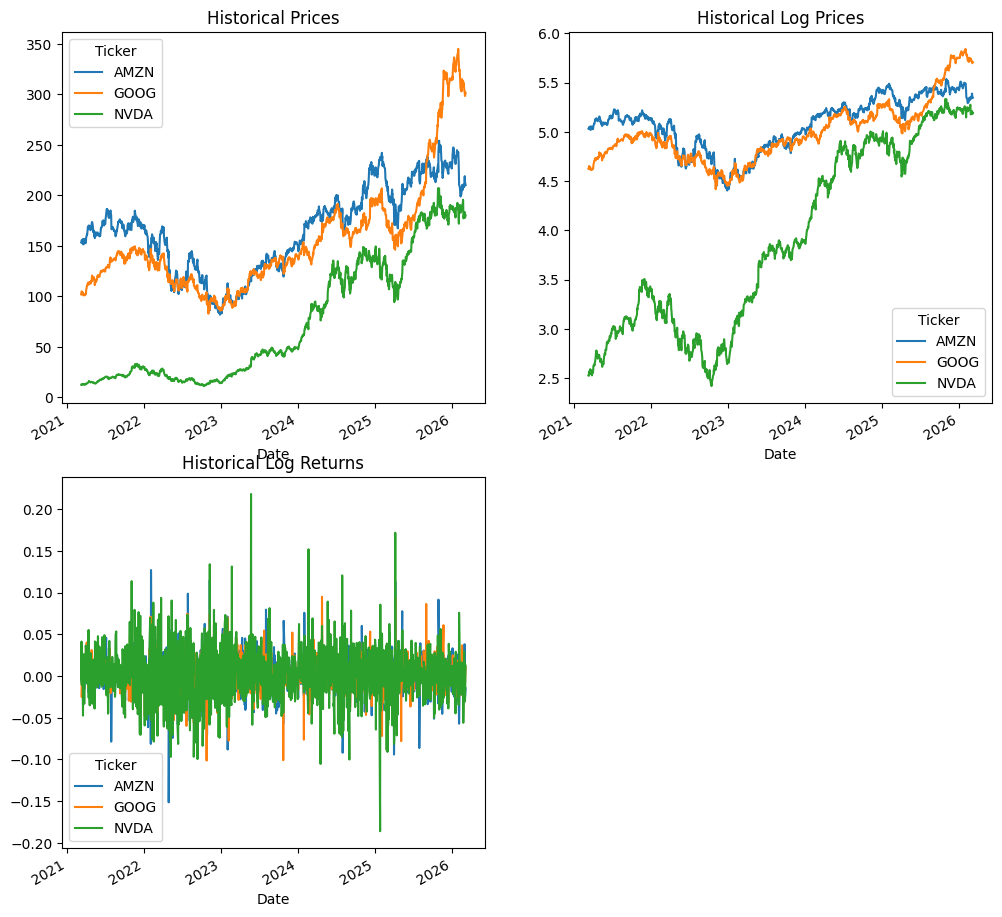

In [24]:
import matplotlib.pyplot as plt
import numpy as np
fig = plt.figure(figsize=[12,12])
ax1 = fig.add_subplot(221)
df.plot(title='Historical Prices', ax=ax1)

ax2 = fig.add_subplot(222)
log_prices = np.log(df)
log_prices.plot(title='Historical Log Prices', ax=ax2)

ax3 = fig.add_subplot(223)
log_returns = np.log(df).diff()
log_returns.plot(title='Historical Log Returns', ax=ax3)

In [25]:
corr_matrix= log_returns.corr()
corr_matrix

Ticker,AMZN,GOOG,NVDA
Ticker,,,
AMZN,1.000000,0.622122,0.549552
GOOG,0.622122,1.000000,0.524003
NVDA,0.549552,0.524003,1.000000


In [26]:
cov_matrix = log_returns.cov()
cov_matrix

Ticker,AMZN,GOOG,NVDA
Ticker,,,
AMZN,0.000492,0.000266,0.000394
GOOG,0.000266,0.000370,0.000326
NVDA,0.000394,0.000326,0.001045


If $A$ is symmetric **semi positive definite** (SPD) matrix
- $A$ can be decomposed as $A=LL^T$, where $L$ is lower triangle
- $L$ can be viewed as the "square root" of $A$

Cholesky decomposition is not unique if the matrix is semi positive definited, but unique when it is positive definite:
- The rank is same between $L$ and $A$
- Beware that $A=LL^T\neq L^TL$

In [30]:
from IPython.display import display, Math
import sympy as sp
def print_latex(*args):
    return display(Math("".join(f"{sp.latex(a) if not isinstance(a,str) else a}" for a in args)))

In [39]:
L_corr_matrix = np.linalg.cholesky(corr_matrix)
print_latex('Corr=', sp.Matrix(corr_matrix))
print_latex("LL^T=",sp.Matrix(L_corr_matrix), sp.Matrix(L_corr_matrix.T), '=', sp.Matrix(L_corr_matrix@L_corr_matrix.T))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [42]:
L_cov_matrix = np.linalg.cholesky(cov_matrix)
print_latex('Cov=', sp.Matrix(cov_matrix))
print_latex("LL^T=",sp.Matrix(L_cov_matrix), sp.Matrix(L_cov_matrix.T), '=', sp.Matrix(L_cov_matrix@L_cov_matrix.T))

<IPython.core.display.Math object>

<IPython.core.display.Math object>